In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


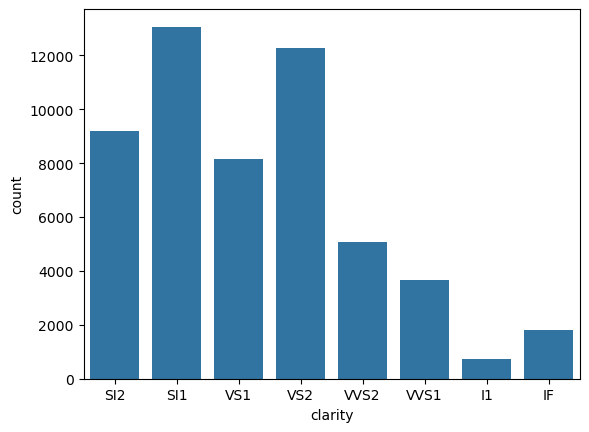

In [4]:
sns.countplot(data=df, x="clarity")
plt.show()

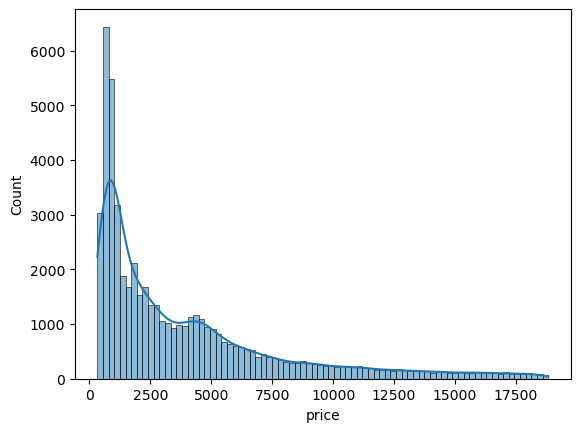

In [5]:
sns.histplot(df["price"], kde=True)
plt.show()

In [6]:
df.corr(numeric_only=True)["price"].sort_values(ascending=False)

price    1.000000
carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64

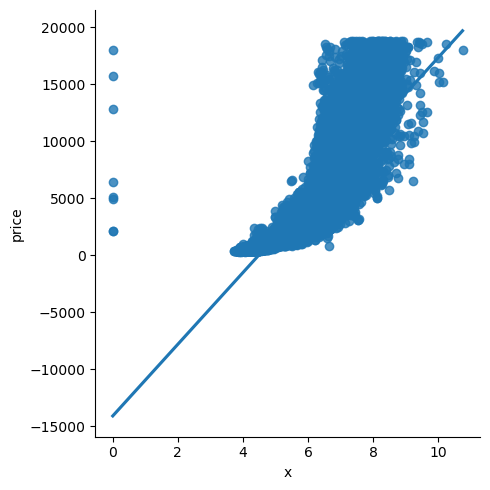

In [7]:
sns.lmplot(data=df, x="x", y="price")
plt.show()

In [8]:
X = df.drop("price", axis=1)
y = df.price

In [9]:
# train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [10]:
# CatBoost Regressor
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.04,
    depth=8,
    l2_leaf_reg=4,
    loss_function="RMSE",
    cat_features=["cut", "color", "clarity"],
    random_state=42,
    verbose=100,
    early_stopping_rounds=50
)

In [11]:
# Train
model.fit(X_train, y_train)

0:	learn: 3850.2675396	total: 169ms	remaining: 1m 24s
100:	learn: 631.1600739	total: 7.01s	remaining: 27.7s
200:	learn: 554.4916543	total: 12.9s	remaining: 19.2s
300:	learn: 530.8062714	total: 19.1s	remaining: 12.6s
400:	learn: 517.4887759	total: 24.8s	remaining: 6.13s
499:	learn: 506.2022577	total: 30.5s	remaining: 0us


In [12]:
# testing
y_pred = model.predict(X_test)

In [17]:
# evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2 Score: ", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE", mean_absolute_error(y_test, y_pred))

R2 Score:  0.9819938476350271
MSE: 290736.02288329694
MAE 282.00476583235877


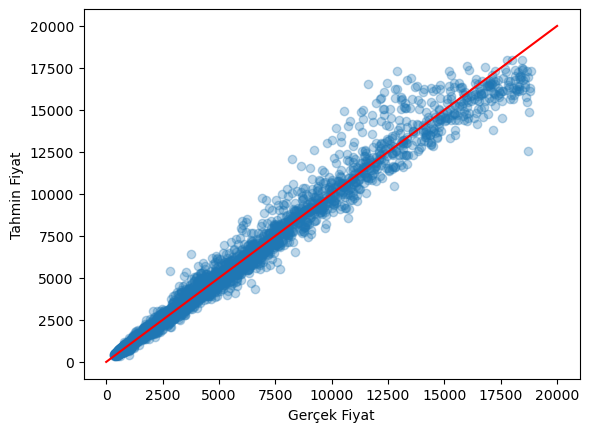

In [18]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0,20000], [0,20000], color = "red")
plt.xlabel("Gerçek Fiyat")
plt.ylabel("Tahmin Fiyat")
plt.show()